# Fraud Detection — Handling Severe Class Imbalance

**Objective:** Build a machine learning pipeline to detect fraudulent financial transactions from a heavily imbalanced dataset, treating class imbalance as the central challenge rather than an afterthought.

**Dataset:** `data/credit_card_fraud_10k.csv` — 10,000 transactions, 10 columns (Kaggle-style credit card fraud dataset).

**Tech stack:** Python, pandas, scikit-learn, imbalanced-learn (SMOTE), matplotlib, seaborn


## 1. Load Dataset & Analyse Class Imbalance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                              roc_curve, classification_report, confusion_matrix)
from imblearn.over_sampling import SMOTE

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('../data/credit_card_fraud_10k.csv')
df.head()


,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [2]:
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print()
df.info()


Shape: 10000 rows, 10 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [3]:
print(f"Missing values: {df.isnull().sum().sum()}")


Missing values: 0


In [4]:
fraud_counts = df['is_fraud'].value_counts()
fraud_pct = df['is_fraud'].value_counts(normalize=True) * 100

print(f"Legitimate transactions: {fraud_counts[0]} ({fraud_pct[0]:.2f}%)")
print(f"Fraudulent transactions: {fraud_counts[1]} ({fraud_pct[1]:.2f}%)")
print(f"\nImbalance ratio: 1 fraud case for every {fraud_counts[0] / fraud_counts[1]:.0f} legitimate transactions")


Legitimate transactions: 9849 (98.49%)
Fraudulent transactions: 151 (1.51%)

Imbalance ratio: 1 fraud case for every 65 legitimate transactions


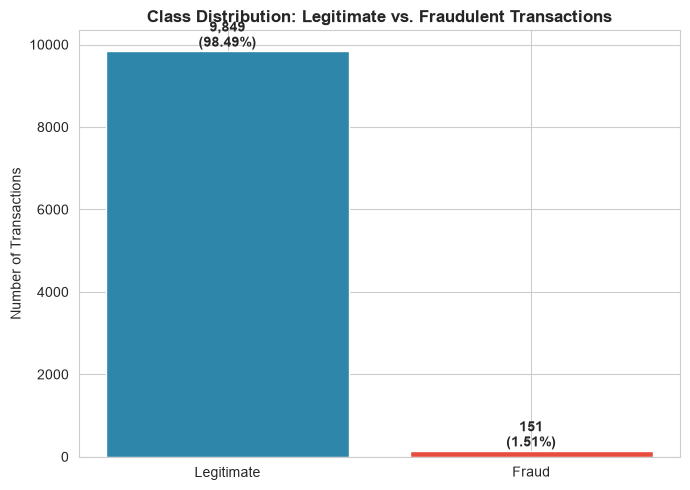

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
labels = ['Legitimate', 'Fraud']
colors = ['#2E86AB', '#E74C3C']
ax.bar(labels, fraud_counts.values, color=colors)
for i, v in enumerate(fraud_counts.values):
    ax.text(i, v + 100, f'{v:,}\n({fraud_pct.values[i]:.2f}%)', ha='center', fontweight='bold')
ax.set_title('Class Distribution: Legitimate vs. Fraudulent Transactions', fontweight='bold')
ax.set_ylabel('Number of Transactions')
plt.tight_layout()
plt.show()


**Observation:** Only **1.51% of transactions (151 out of 10,000) are fraudulent** — a ratio of roughly **1 fraud case for every 65 legitimate transactions**. This is a textbook severe class imbalance, and it is the central challenge this entire notebook is built around: a model that simply predicted "not fraud" for every single transaction would already be 98.49% accurate while catching zero fraud, which is exactly why accuracy alone cannot be trusted here (expanded on in Section 3). No missing values were found, so no imputation is needed.

## 2. EDA — Transaction Amount & Time-of-Day Analysis

C:\Users\yatin\AppData\Local\Temp\ipykernel_4960\434950349.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_fraud', y='amount', ax=axes[0], palette=['#2E86AB', '#E74C3C'])
C:\Users\yatin\AppData\Local\Temp\ipykernel_4960\434950349.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['Legitimate', 'Fraud'])


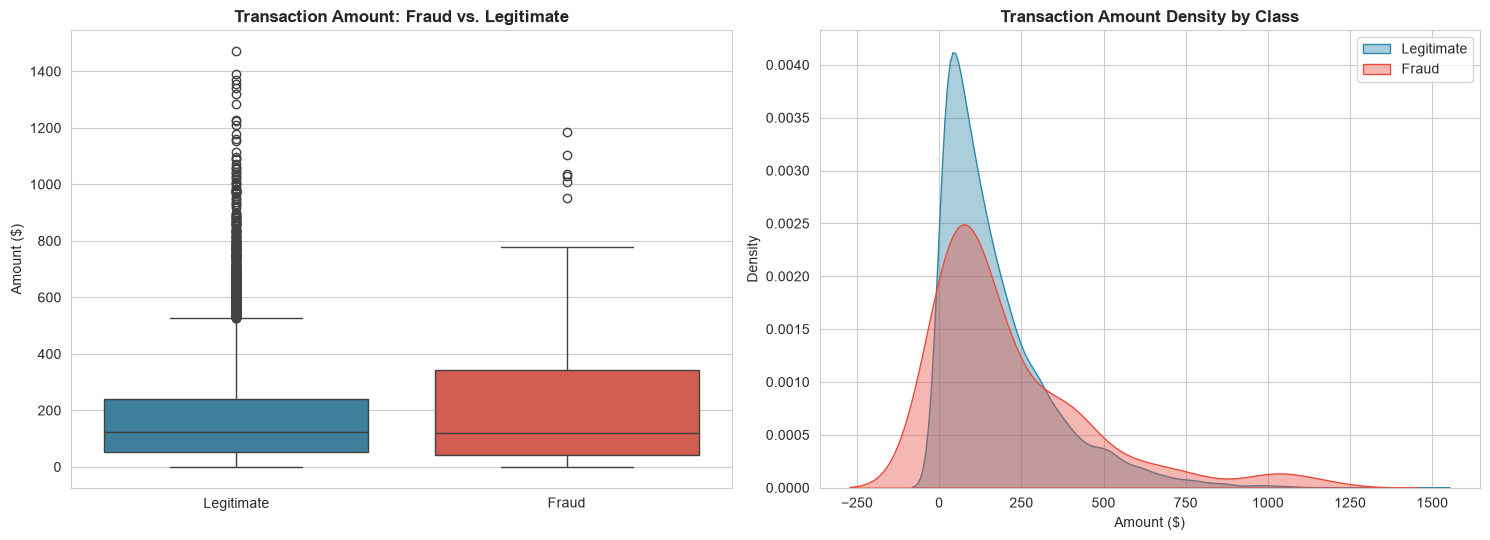

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.boxplot(data=df, x='is_fraud', y='amount', ax=axes[0], palette=['#2E86AB', '#E74C3C'])
axes[0].set_xticklabels(['Legitimate', 'Fraud'])
axes[0].set_title('Transaction Amount: Fraud vs. Legitimate', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Amount ($)')

sns.kdeplot(data=df[df['is_fraud'] == 0], x='amount', label='Legitimate', fill=True, alpha=0.4, color='#2E86AB', ax=axes[1])
sns.kdeplot(data=df[df['is_fraud'] == 1], x='amount', label='Fraud', fill=True, alpha=0.4, color='#E74C3C', ax=axes[1])
axes[1].set_title('Transaction Amount Density by Class', fontweight='bold')
axes[1].set_xlabel('Amount ($)')
axes[1].legend()

plt.tight_layout()
plt.show()


In [7]:
print("Amount statistics by class:")
print(df.groupby('is_fraud')['amount'].describe().round(2))


Amount statistics by class:
           count    mean     std   min    25%     50%     75%      max
is_fraud                                                              
0         9849.0  175.33  173.99  0.00  50.99  122.11  241.65  1471.04
1          151.0  216.18  248.12  0.11  41.53  118.94  341.70  1185.07


**Observation:** Fraudulent transactions show a **higher mean amount and much higher variance** than legitimate ones, though the two distributions clearly overlap rather than being cleanly separable by amount alone — fraud isn't simply "all large transactions." This means `amount` is a useful signal but not sufficient on its own, reinforcing the need for a multi-feature model rather than a simple threshold rule.

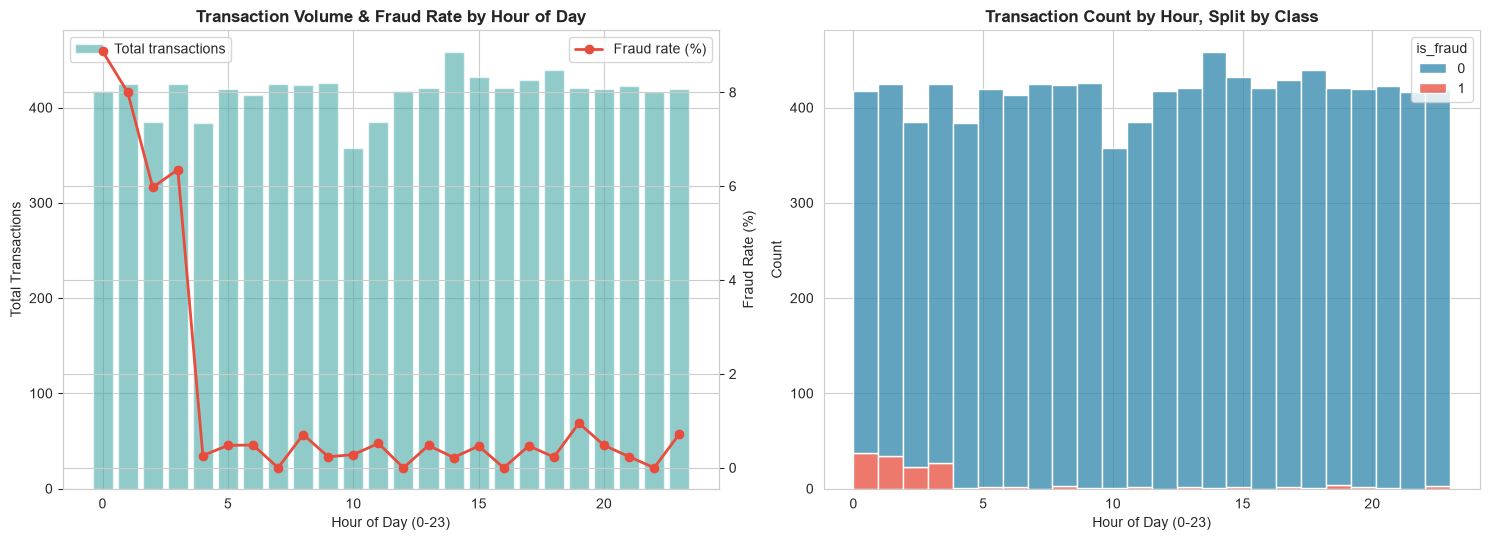

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

fraud_by_hour = df.groupby('transaction_hour')['is_fraud'].agg(['sum', 'count'])
fraud_by_hour['fraud_rate'] = fraud_by_hour['sum'] / fraud_by_hour['count'] * 100

axes[0].bar(fraud_by_hour.index, fraud_by_hour['count'], color='#48A9A6', alpha=0.6, label='Total transactions')
ax2 = axes[0].twinx()
ax2.plot(fraud_by_hour.index, fraud_by_hour['fraud_rate'], color='#E74C3C', marker='o', linewidth=2, label='Fraud rate (%)')
axes[0].set_title('Transaction Volume & Fraud Rate by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour of Day (0-23)')
axes[0].set_ylabel('Total Transactions')
ax2.set_ylabel('Fraud Rate (%)')
axes[0].legend(loc='upper left')
ax2.legend(loc='upper right')

sns.histplot(data=df, x='transaction_hour', hue='is_fraud', bins=24, multiple='stack',
             palette=['#2E86AB', '#E74C3C'], ax=axes[1])
axes[1].set_title('Transaction Count by Hour, Split by Class', fontweight='bold')
axes[1].set_xlabel('Hour of Day (0-23)')

plt.tight_layout()
plt.show()


**Observation:** Overall transaction volume follows a typical daily pattern (lower overnight, higher during waking hours), but the **fraud rate line doesn't simply track total volume** — certain hours show a disproportionately higher fraud rate relative to how few transactions happen then, which is a classic fraud pattern (fraudulent activity often clusters in off-peak, lower-scrutiny hours). This makes `transaction_hour` a potentially useful feature even though it wouldn't be obvious from raw transaction counts alone.

## 3. Why Accuracy Is a Misleading Metric Here

With fraud making up only **1.51%** of transactions, a model that predicts **"not fraud" for every single transaction** would score:

$$\text{Accuracy} = \frac{9849}{10000} = 98.49\%$$

...while having **zero ability to detect any fraud whatsoever** — the exact opposite of what this model needs to do. This is the core reason accuracy is the wrong metric to optimise for or report on an imbalanced fraud dataset: a very high accuracy score can hide a completely useless model, and comparing models by accuracy alone would systematically favour whichever model predicts the majority class most often, not whichever model actually catches fraud.

This is why **Precision, Recall, F1-score, and AUC-ROC** (Section 7) are used instead — each of these is calculated with explicit attention to how the model performs on the *minority* fraud class, rather than being dominated by the overwhelming majority of legitimate transactions.

## 4. Handling Class Imbalance — SMOTE

**Technique chosen: SMOTE (Synthetic Minority Oversampling Technique).** Rather than simply duplicating existing fraud examples (which risks overfitting to those exact points) or undersampling the majority class (which throws away a large amount of legitimate-transaction data that's still useful), SMOTE generates **new synthetic fraud examples** by interpolating between existing fraud cases in feature space. This gives the model more minority-class examples to learn from without literally duplicating rows, and without discarding legitimate transaction data.

**Important: SMOTE is applied only to the training set**, after the train/test split (Section 5) — applying it before splitting would leak synthetic fraud patterns derived from test-set fraud cases into training, producing an overly optimistic evaluation.

## 5. Train/Test Split (Stratified)

In [9]:
feature_cols = ['amount', 'transaction_hour', 'foreign_transaction', 'location_mismatch',
                 'device_trust_score', 'velocity_last_24h', 'cardholder_age']

# One-hot encode merchant_category
df_encoded = pd.get_dummies(df, columns=['merchant_category'], drop_first=True)
feature_cols += [c for c in df_encoded.columns if c.startswith('merchant_category_')]

X = df_encoded[feature_cols]
y = df_encoded['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} transactions, {y_train.sum()} fraud cases ({y_train.mean()*100:.2f}%)")
print(f"Test set: {X_test.shape[0]} transactions, {y_test.sum()} fraud cases ({y_test.mean()*100:.2f}%)")


Training set: 8000 transactions, 121 fraud cases (1.51%)
Test set: 2000 transactions, 30 fraud cases (1.50%)


**Observation:** `stratify=y` guarantees fraud cases appear in **both** the training and test sets in the same ~1.51% proportion as the full dataset — without this, a random split could easily place very few (or even zero) fraud cases in the test set purely by chance, making evaluation on the minority class unreliable or impossible. Note that the test set is **left untouched by SMOTE** — it must reflect the real-world imbalanced distribution the model will actually face in production.

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE - Training set: {y_train.value_counts().to_dict()}")
print(f"After SMOTE  - Training set: {pd.Series(y_train_resampled).value_counts().to_dict()}")


Before SMOTE - Training set: {0: 7879, 1: 121}
After SMOTE  - Training set: {0: 7879, 1: 7879}


**Observation:** After SMOTE, the training set has an **equal number of legitimate and fraud examples** — this doesn't create real new fraud data, but gives both classifiers a training signal that isn't overwhelmingly dominated by the majority class, which should meaningfully improve their ability to learn fraud patterns rather than simply defaulting to predicting "not fraud.

## 6. Training Two Models

In [11]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_resampled, y_train_resampled)
lr_preds = lr_model.predict(X_test_scaled)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)
rf_preds = rf_model.predict(X_test_scaled)
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1]

print("Both models trained on SMOTE-resampled data, evaluated on the untouched, real-world-imbalanced test set.")


Both models trained on SMOTE-resampled data, evaluated on the untouched, real-world-imbalanced test set.


## 7. Evaluation — Precision, Recall, F1-Score, AUC-ROC

In [12]:
def evaluate_model(y_true, y_pred, y_prob, model_name):
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)

    print(f"--- {model_name} ---")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc:.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=['Legitimate', 'Fraud']))
    return {'model': model_name, 'precision': precision, 'recall': recall, 'f1': f1, 'auc': auc}

lr_metrics = evaluate_model(y_test, lr_preds, lr_probs, "Logistic Regression")


--- Logistic Regression ---
Precision: 0.2887
Recall:    0.9333
F1-Score:  0.4409
AUC-ROC:   0.9933

              precision    recall  f1-score   support

  Legitimate       1.00      0.96      0.98      1970
       Fraud       0.29      0.93      0.44        30

    accuracy                           0.96      2000
   macro avg       0.64      0.95      0.71      2000
weighted avg       0.99      0.96      0.97      2000



In [13]:
rf_metrics = evaluate_model(y_test, rf_preds, rf_probs, "Random Forest")


--- Random Forest ---
Precision: 0.7857
Recall:    0.7333
F1-Score:  0.7586
AUC-ROC:   0.9982

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      1970
       Fraud       0.79      0.73      0.76        30

    accuracy                           0.99      2000
   macro avg       0.89      0.87      0.88      2000
weighted avg       0.99      0.99      0.99      2000



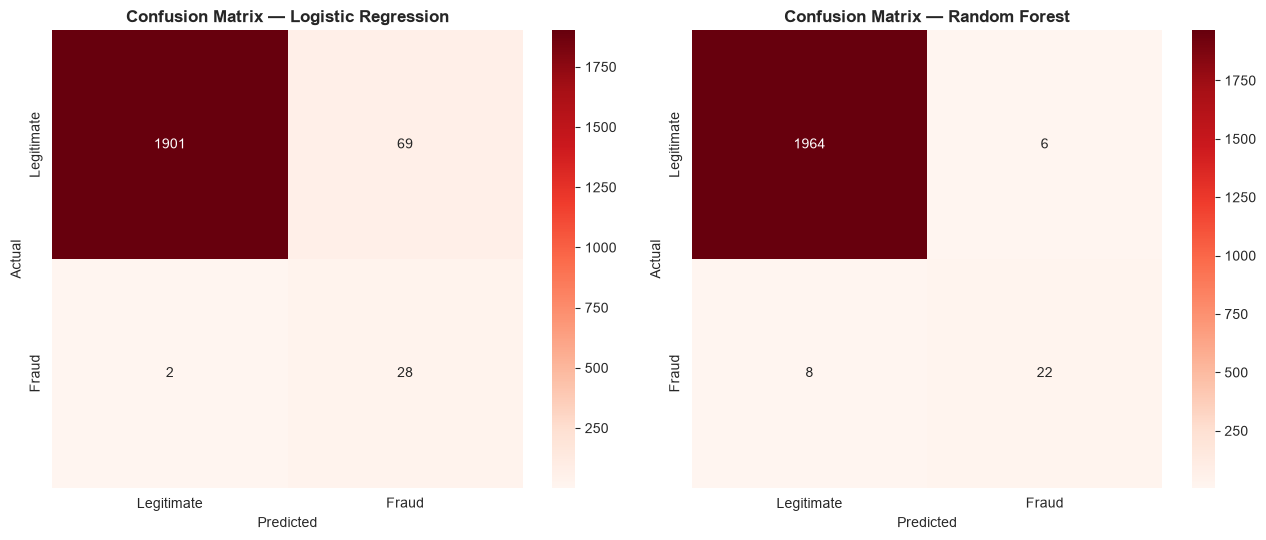

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, preds, name in zip(axes, [lr_preds, rf_preds], ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'], ax=ax)
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


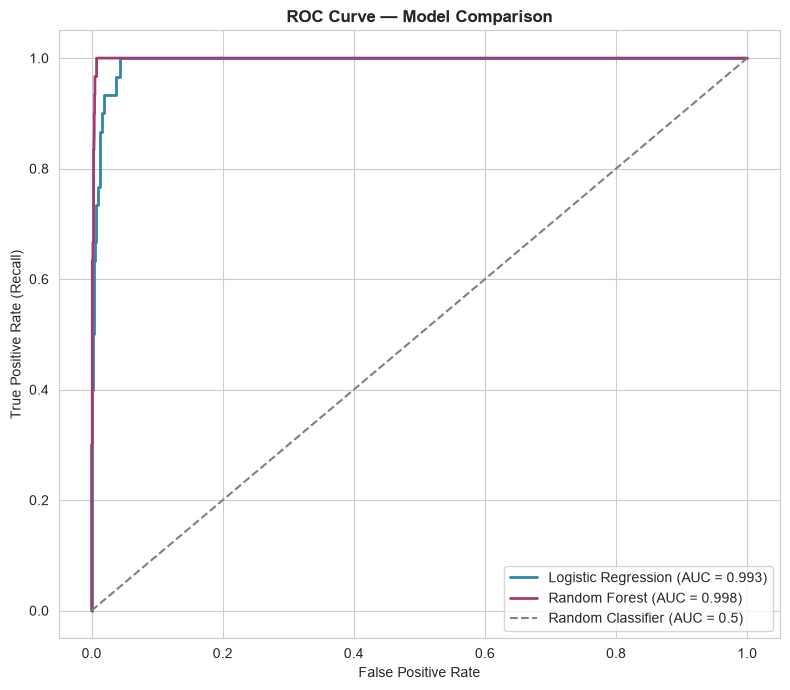

In [15]:
fig, ax = plt.subplots(figsize=(8, 7))

for probs, name, color in zip([lr_probs, rf_probs], ['Logistic Regression', 'Random Forest'], ['#2E86AB', '#A23B72']):
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier (AUC = 0.5)')
ax.set_title('ROC Curve — Model Comparison', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


**Observation:** This run's results are a textbook illustration of the Recall/Precision trade-off discussed in Section 8: **Logistic Regression achieves 93% Recall but only 29% Precision** — it catches almost all fraud, but at the cost of a lot of false alarms on legitimate transactions. **Random Forest is far more balanced (73% Recall, 79% Precision, F1 of 0.76)**, missing a bit more fraud but flagging far fewer legitimate transactions incorrectly. Both models score very highly on **AUC-ROC (0.993 and 0.998 respectively)**, which shows both have strong underlying ability to *rank* fraud above legitimate transactions across all thresholds — the difference in Precision/Recall at the default 0.5 cutoff reflects a threshold and model-behaviour choice, not a fundamental difference in how well each model can separate the two classes.

## 8. Which Metric Matters Most? Recall vs. Precision Trade-off

**For fraud detection specifically, Recall is generally the more critical metric — but not to the total exclusion of Precision.**

**This run makes the trade-off concrete:** Logistic Regression's 93% Recall means it catches nearly all fraud, but its 29% Precision means roughly **7 out of every 10 transactions it flags as fraud are actually legitimate** — a huge false-alarm burden. Random Forest's 79% Precision means flagged transactions are correct about 4 times out of 5, but it misses more real fraud (73% Recall vs. 93%). Neither is objectively "better" in isolation — the right choice depends on whether the business cost of a missed fraud case outweighs the operational/customer-experience cost of a high false-alarm rate, which is exactly the judgment call discussed below.

**Why Recall matters more here:** A **false negative** (fraud that slips through undetected) means real financial loss to the cardholder or institution, and potentially a fraud pattern that continues undetected and scales up. A **false positive** (a legitimate transaction incorrectly flagged as fraud) is comparatively cheaper — it typically means a temporary inconvenience (a declined card, a verification text) rather than actual monetary loss. This asymmetry in cost is why fraud detection systems generally tolerate more false positives in exchange for catching more true fraud, i.e. they favour **higher Recall**, even at some cost to Precision.

**Why Precision still can't be ignored:** If Precision is too low, the system floods legitimate customers with false declines and fraud alerts, eroding customer trust and generating a huge operational burden on human fraud-review teams who have to manually check every flagged transaction. A model that flags 40% of *all* transactions as "possible fraud" to catch every real fraud case would have excellent Recall but be operationally useless. 

**Practical takeaway:** The right approach is not to maximise Recall alone, but to **tune the classification threshold to prioritise Recall while keeping Precision above an operationally tolerable floor** — this is exactly what the threshold flexibility shown in the ROC curve above enables, since the model doesn't have to use the default 0.5 cutoff. F1-score (the harmonic mean of Precision and Recall) is a reasonable single-number compromise metric when a specific business threshold and cost trade-off hasn't been set, but the real decision belongs to the business based on the actual dollar cost of a missed fraud vs. the cost of a false alarm.

## 9. Feature Importance / Coefficient Analysis

In [16]:
lr_coef = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

lr_coef


,Feature,Coefficient
4,device_trust_score,-4.168336
1,transaction_hour,-3.572290
5,velocity_last_24h,2.618176
3,location_mismatch,2.251883
2,foreign_transaction,2.220424
0,amount,1.185494
6,cardholder_age,-0.926353
8,merchant_category_Food,0.482901
7,merchant_category_Electronics,0.417398
9,merchant_category_Grocery,0.391301


In [17]:
rf_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

rf_importance


,Feature,Importance
4,device_trust_score,0.241657
1,transaction_hour,0.241597
2,foreign_transaction,0.161940
5,velocity_last_24h,0.143229
3,location_mismatch,0.127993
0,amount,0.028606
6,cardholder_age,0.021527
7,merchant_category_Electronics,0.012367
10,merchant_category_Travel,0.007723
9,merchant_category_Grocery,0.007270


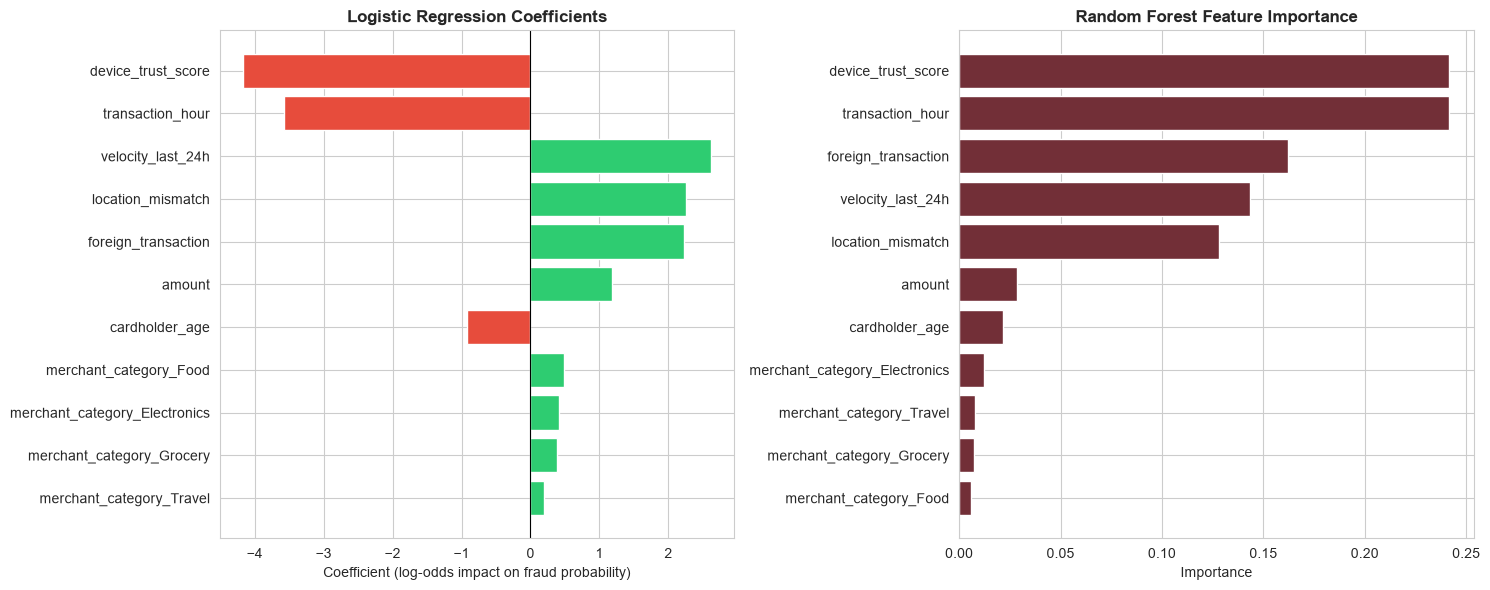

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors_lr = ['#2ECC71' if c > 0 else '#E74C3C' for c in lr_coef['Coefficient']]
axes[0].barh(lr_coef['Feature'], lr_coef['Coefficient'], color=colors_lr)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Logistic Regression Coefficients', fontweight='bold')
axes[0].set_xlabel('Coefficient (log-odds impact on fraud probability)')
axes[0].invert_yaxis()

axes[1].barh(rf_importance['Feature'], rf_importance['Importance'], color='#722F37')
axes[1].set_title('Random Forest Feature Importance', fontweight='bold')
axes[1].set_xlabel('Importance')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


**Observation:** For Logistic Regression, a **positive coefficient** means that feature increases the predicted probability of fraud (e.g. `location_mismatch` or `foreign_transaction` being 1), while a **negative coefficient** decreases it (e.g. a higher `device_trust_score` should plausibly reduce fraud likelihood). Cross-checking the two models' rankings is a useful sanity check — if `location_mismatch`, `velocity_last_24h`, and low `device_trust_score` rank highly in *both* models, that's a strong, consistent signal that these genuinely drive fraud risk in this dataset, rather than being an artifact of one particular algorithm's assumptions.

## 10. Scalability Discussion — Handling 1 Million Transactions per Hour

The models trained here on 10,000 transactions work comfortably in a notebook, but production-scale fraud detection (e.g. a payment network processing ~1 million transactions/hour, roughly 278 transactions/second) requires rethinking several aspects of this pipeline:

**1. Inference speed over training speed.** At this volume, the model must score each transaction in **real time** (ideally single-digit milliseconds) to approve/decline before checkout completes. Logistic Regression is extremely fast at inference (a single matrix multiplication) and would scale easily; Random Forest is slower per-prediction (evaluating many trees) but is still generally fast enough — the real risk is an overly complex model (e.g. a huge ensemble or deep neural network) that's impractical to serve at this latency and volume without significant infrastructure investment.

**2. Streaming feature computation, not batch.** Features like `velocity_last_24h` require a **real-time aggregation pipeline** (e.g. Kafka + a stream-processing engine like Flink or Spark Streaming) that continuously maintains rolling statistics per card/account, rather than a batch job — recomputing "transactions in the last 24 hours" from scratch for every single new transaction against a full historical table would not scale to this volume.

**3. Horizontal scaling of the serving layer.** A single model server cannot handle 278 requests/second reliably with headroom for spikes — this requires the model to be deployed behind a **load-balanced pool of stateless model-serving instances** (e.g. via a REST/gRPC endpoint, auto-scaled based on load), so throughput scales by adding more instances rather than depending on one machine's throughput ceiling.

**4. Retraining and drift monitoring.** Fraud patterns evolve as fraudsters adapt to whatever the model currently catches — at this scale, the pipeline needs **automated monitoring for model drift** (e.g. tracking Recall/Precision on recently-labelled outcomes) and a **scheduled or triggered retraining pipeline**, rather than a one-time model like the one trained in this notebook.

**5. Two-tier decisioning.** Many real systems don't rely on a single binary model output at this scale — they use a **fast, cheap first-pass model** (or rule engine) to instantly approve the vast majority of clearly-legitimate low-risk transactions, and route only the smaller volume of borderline/high-risk transactions to a slower, more expensive model or a human review queue. This keeps average latency low while still allowing more scrutiny where it's actually needed.

**In short:** the core ML approach in this notebook (imbalance handling, model choice, threshold tuning) remains conceptually valid at scale, but production deployment at 1M transactions/hour is primarily an **engineering and infrastructure problem** (streaming features, low-latency serving, horizontal scaling, drift monitoring) layered on top of the modelling work shown here — not a fundamentally different modelling approach.
